In [ ]:
!pip install rioxarray rasterio xarray pystac-client planetary-computer geopandas odc.stac stackstac
!pip install --upgrade rasterio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.4/41.4 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.3/64.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.8/206.8 kB 14.6 MB/s eta 0:00:00


In [170]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
#import seaborn as sns

# Data Science
import numpy as np
import pandas as pd

# Multi-dimensional arrays and datasets
import xarray as xr

# Geospatial raster data handling
import rioxarray as rxr

# Geospatial data analysis
#import geopandas as gpd

# Geospatial operations
import rasterio
from rasterio import windows
from rasterio import features
from rasterio import warp
from rasterio.warp import transform_bounds
from rasterio.windows import from_bounds

# Image Processing
from PIL import Image

# Coordinate transformations
from pyproj import Proj, Transformer, CRS

# Feature Engineering
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow import keras
import tf_keras as keras  # Use tf_keras instead of tf.keras
from tf_keras import layers
from tf_keras.models import Model, Sequential
from tf_keras.layers import Input, Dropout, Dense
from tf_keras.optimizers import Adam
import tensorflow_probability as tfp
import tensorflow_probability.python.layers as tfpl
tfd = tfp.distributions
from tf_keras.callbacks import CSVLogger

# Planetary Computer Tools
import pystac_client
import planetary_computer as pc
from pystac.extensions.eo import EOExtension as eo

# Others
import os
from tqdm import tqdm



In [ ]:
def combine_two_datasets(dataset1,dataset2):
    '''
    Returns a  vertically concatenated dataset.
    Attributes:
    dataset1 - Dataset 1 to be combined
    dataset2 - Dataset 2 to be combined
    '''

    data = pd.concat([dataset1,dataset2], axis=1)
    return data

In [ ]:
# Extracts satellite band values from a GeoTIFF based on coordinates from a csv file and returns them in a DataFrame.
from google.colab import files
def map_satellite_data(tiff_path, csv_path):

    # Load the GeoTIFF data
    data = rxr.open_rasterio(tiff_path)
    tiff_crs = data.rio.crs

    # Read the Excel file using pandas
    df = pd.read_csv(csv_path)
    latitudes = df['Latitude'].values
    longitudes = df['Longitude'].values

    # 3. Convert lat/long to the GeoTIFF's CRS
    # Create a Proj object for EPSG:4326 (WGS84 - lat/long) and the GeoTIFF's CRS
    proj_wgs84 = Proj(init='epsg:4326')  # EPSG:4326 is the common lat/long CRS
    proj_tiff = Proj(tiff_crs)

    # Create a transformer object
    transformer = Transformer.from_proj(proj_wgs84, proj_tiff)

    vals = [[] for _ in range(n_inputs)]


# Iterate over the latitudes and longitudes, and extract the corresponding band values
    for lat, lon in tqdm(zip(latitudes, longitudes), total=len(latitudes), desc="Mapping values"):
    # Assuming the correct dimensions are 'y' and 'x' (replace these with actual names from data.coords)

        for i in range(n_inputs):
            tmp = data.sel(x=lon, y=lat, band=i, method='nearest').values
            vals[i].append(tmp)

    # Create a DataFrame with the band values
    # Create a DataFrame to store the band values
    df = pd.DataFrame()
    for i in range(n_inputs):
        df[names[i]] = vals[i]

    return df

def map_wind_data(csv_path, excel_path):
    excel_file = pd.ExcelFile(excel_path)
    df = excel_file.parse(4)
    df.to_csv

In [ ]:
# Constants
n_inputs = 28
names = ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12", "ndwi", "ndvi", "ndbi",
        "B01 (pooled)", "B02 (pooled)", "B03 (pooled)", "B04 (pooled)", "B05 (pooled)", "B06 (pooled)", "B07 (pooled)", "B08 (pooled)", "B8A (pooled)", "B11 (pooled)", "B12 (pooled)", "ndwi (pooled)", "ndvi (pooled)", "ndbi (pooled)",
        "building_count_0-25ft", "building_impact_0-25ft", "building_count_25-50ft", "building_impact_25-50ft", "building_count_50-100ft", "building_impact_50-100ft", "building_count_100-200ft", "building_impact_100-200ft", "building_count_200-500ft", "building_impact_200-500ft",
        "tree_count_0-25ft", "tree_impact_0-25ft", "tree_count_25-50ft", "tree_impact_25-50ft", "tree_count_50-100ft", "tree_impact_50-100ft", "tree_count_100-200ft", "tree_impact_100-200ft", "tree_count_200-500ft", "tree_impact_200-500ft"]
UhiData_FileName = "Data/Training_data_uhi_index.csv"
satellite_data =  "Data/S2_median_fullBands_indeces.tiff"
tree_building_uhi_data = "Data/LATEST_combined_tree_building_uhi_features.csv"
test_size = 0.3

# Open the GeoTIFF file
tiff_path = "Data/S2_median_fullBands_indeces.tiff"

In [ ]:
# Would be faster in a df
feature_data = map_satellite_data(satellite_data, UhiData_FileName)


Mapping values:   1%|          | 128/11229 [00:05<08:38, 21.42it/s]


KeyboardInterrupt: 

In [127]:
print(feature_data)

         B01    B02     B03     B04     B05     B06     B07     B08     B8A  \
0      841.5  841.5  1053.0  1155.0  1206.0  1481.5  1660.5  1721.0  1832.0   
1      841.5  841.5  1053.0  1155.0  1206.0  1481.5  1660.5  1721.0  1832.0   
2      841.5  841.5   646.0   823.0   777.0  1130.5  1883.0  2117.5  2241.0   
3      841.5  841.5   625.0   766.0   741.5  1130.5  1883.0  2117.5  2200.0   
4      841.5  841.5   659.5   763.0   708.5  1077.5  1783.0  2042.0  2161.0   
...      ...    ...     ...     ...     ...     ...     ...     ...     ...   
11224  462.5  462.5   491.0   725.5   501.0   999.0  2612.0  3111.5  3152.0   
11225  462.5  462.5   506.5   741.5   551.5   999.0  2612.0  3111.5  3572.0   
11226  462.5  462.5   506.5   741.5   551.5   999.0  2612.0  3111.5  3572.0   
11227  462.5  462.5   506.5   741.5   551.5   999.0  2612.0  3111.5  3572.0   
11228  462.5  462.5   640.0   835.0   723.0  1014.5  2755.0  3407.5  3341.0   

          B11  ...  B05 (pooled)  B06 (pooled)  B07

In [128]:
import re
# Identify object columns
object_cols = feature_data.select_dtypes(include=['object']).columns

# Convert to numeric
for col in object_cols:
    feature_data[col] = pd.to_numeric(feature_data[col], errors='coerce')

object_cols = feature_data.select_dtypes(include=['object']).columns

# Clean up inconsistencies (example for one column)
for col in ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12',
            "B01 (pooled)", "B02 (pooled)", "B03 (pooled)", "B04 (pooled)", "B05 (pooled)", "B06 (pooled)", "B07 (pooled)", "B08 (pooled)", "B8A (pooled)", "B11 (pooled)",
            "B12 (pooled)"]:
    feature_data[col] = feature_data[col].apply(lambda x: tuple(x) if isinstance(x, np.ndarray) and x.ndim > 0 else x)

# Convert to numeric
for col in ['B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12',
            "B01 (pooled)", "B02 (pooled)", "B03 (pooled)", "B04 (pooled)", "B05 (pooled)", "B06 (pooled)", "B07 (pooled)", "B08 (pooled)", "B8A (pooled)", "B11 (pooled)",
            "B12 (pooled)"]:
    feature_data[col] = pd.to_numeric(feature_data[col], errors='coerce')
    print(feature_data[col].dtype)
# Redo columns
epsilon = 1e-10  # A small constant to avoid division by zero
feature_data["ndwi"] = (feature_data["B03"] - feature_data["B08"]) / (feature_data["B03"] + feature_data["B08"] + epsilon)
feature_data["ndbi"] = (feature_data["B11"] - feature_data["B08"]) / (feature_data["B11"] + feature_data["B08"] + epsilon)
feature_data["ndvi"] = (feature_data["B08"] - feature_data["B04"]) / (feature_data["B08"] + feature_data["B04"] + epsilon)
feature_data["ndwi (pooled)"] = (feature_data["B03 (pooled)"] - feature_data["B08 (pooled)"]) / (feature_data["B03 (pooled)"] + feature_data["B08 (pooled)"] + epsilon)
feature_data["ndbi (pooled)"] = (feature_data["B11 (pooled)"] - feature_data["B08 (pooled)"]) / (feature_data["B11 (pooled)"] + feature_data["B08 (pooled)"] + epsilon)
feature_data["ndvi (pooled)"] = (feature_data["B08 (pooled)"] - feature_data["B04 (pooled)"]) / (feature_data["B08 (pooled)"] + feature_data["B04 (pooled)"] + epsilon)


float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64
float64


In [157]:
# Combining ground data and feature data into a single dataset.
ground_df = pd.read_csv(UhiData_FileName)
tree_building_df = pd.read_csv(tree_building_uhi_data)
uhi_data = combine_two_datasets(ground_df,feature_data)
uhi_data = combine_two_datasets(uhi_data, tree_building_df)

uhi_data

,Longitude,Latitude,datetime,UHI Index,B01,B02,B03,B04,B05,B06,...,tree_count_50-100ft,tree_impact_50-100ft,tree_count_100-200ft,tree_impact_100-200ft,tree_count_200-500ft,tree_impact_200-500ft,closest_tree_distance,closest_tree_dbh,longitude,latitude
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,841.5,841.5,1053.0,1155.0,1206.0,1481.5,...,2.0,25.845166,13.0,382.989385,51.0,694.608498,40.498933,5.0,-73.909167,40.813107
1,-73.909187,40.813045,24-07-2021 15:53,1.030289,841.5,841.5,1053.0,1155.0,1206.0,1481.5,...,4.0,40.369974,10.0,332.625902,54.0,740.780352,54.222555,5.0,-73.909187,40.813045
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,841.5,841.5,646.0,823.0,777.0,1130.5,...,4.0,71.716201,9.0,286.517317,53.0,731.532544,44.856958,7.0,-73.909215,40.812978
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,841.5,841.5,625.0,766.0,741.5,1130.5,...,2.0,51.704779,8.0,249.112379,52.0,671.714205,18.688324,7.0,-73.909242,40.812908
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,841.5,841.5,659.5,763.0,708.5,1077.5,...,1.0,10.949187,6.0,174.116477,52.0,723.484668,9.012552,7.0,-73.909257,40.812845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11224,-73.957050,40.790333,24-07-2021 15:57,0.972470,462.5,462.5,491.0,725.5,501.0,999.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,inf,0.0,-73.957050,40.790333
11225,-73.957063,40.790308,24-07-2021 15:57,0.972470,462.5,462.5,506.5,741.5,551.5,999.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,inf,0.0,-73.957063,40.790308
11226,-73.957093,40.790270,24-07-2021 15:57,0.981124,462.5,462.5,506.5,741.5,551.5,999.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,inf,0.0,-73.957093,40.790270
11227,-73.957112,40.790253,24-07-2021 15:59,0.981245,462.5,462.5,506.5,741.5,551.5,999.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,inf,0.0,-73.957112,40.790253


In [162]:
# Old CSV files/dataset
# Remove duplicate rows from the DataFrame based on specified columns and keep the first occurrence
columns_to_check = ['B01','B04','B06','B08','ndvi']
for col in columns_to_check:
    # Check if the value is a numpy array and has more than one dimension
    uhi_data[col] = uhi_data[col].apply(lambda x: tuple(x) if isinstance(x, np.ndarray) and x.ndim > 0 else x)

# Now remove duplicates
uhi_data = uhi_data.drop_duplicates(subset=columns_to_check, keep='first')

# Get a list of column names
cols = list(uhi_data.columns)
uhi_data = uhi_data.loc[:,~uhi_data.columns.duplicated()]
duplicate_col_names = [col for col in cols if cols.count(col) > 1]
print(f"Duplicate column names: {duplicate_col_names}")

uhi_data

Duplicate column names: []


,Longitude,Latitude,datetime,UHI Index,B01,B02,B03,B04,B05,B06,...,tree_count_50-100ft,tree_impact_50-100ft,tree_count_100-200ft,tree_impact_100-200ft,tree_count_200-500ft,tree_impact_200-500ft,closest_tree_distance,closest_tree_dbh,longitude,latitude
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,841.5,841.5,1053.0,1155.0,1206.0,1481.5,...,2.0,25.845166,13.0,382.989385,51.0,694.608498,40.498933,5.0,-73.909167,40.813107
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,841.5,841.5,646.0,823.0,777.0,1130.5,...,4.0,71.716201,9.0,286.517317,53.0,731.532544,44.856958,7.0,-73.909215,40.812978
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,841.5,841.5,625.0,766.0,741.5,1130.5,...,2.0,51.704779,8.0,249.112379,52.0,671.714205,18.688324,7.0,-73.909242,40.812908
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,841.5,841.5,659.5,763.0,708.5,1077.5,...,1.0,10.949187,6.0,174.116477,52.0,723.484668,9.012552,7.0,-73.909257,40.812845
6,-73.909312,40.812710,24-07-2021 15:53,1.015143,841.5,841.5,551.5,768.5,659.0,1077.5,...,1.0,12.113698,3.0,32.561605,54.0,748.122336,35.179383,6.0,-73.909312,40.812710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11219,-73.956957,40.790503,24-07-2021 15:57,0.974633,403.0,403.0,325.0,431.0,290.0,834.5,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,inf,0.0,-73.956957,40.790503
11220,-73.956973,40.790482,24-07-2021 15:57,0.976797,403.0,403.0,318.5,484.0,315.5,834.5,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,inf,0.0,-73.956973,40.790482
11223,-73.957038,40.790360,24-07-2021 15:57,0.972470,462.5,462.5,491.0,725.5,501.0,999.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,inf,0.0,-73.957038,40.790360
11225,-73.957063,40.790308,24-07-2021 15:57,0.972470,462.5,462.5,506.5,741.5,551.5,999.0,...,0.0,0.000000,0.0,0.000000,0.0,0.000000,inf,0.0,-73.957063,40.790308


In [163]:

import pandas as pd
import numpy as np

import pandas as pd
import numpy as np

def idw_interpolation(uhi_data, bronx_wind_data, manhattan_wind_data, power=2):
    """
    Performs Inverse Distance Weighting (IDW) interpolation between Bronx and Manhattan wind data.

    Args:
        uhi_data: DataFrame containing UHI data with 'Latitude' and 'Longitude' columns.
        bronx_wind_data: DataFrame containing Bronx wind data.
        manhattan_wind_data: DataFrame containing Manhattan wind data.
        power: Power parameter for IDW (default: 2).

    Returns:
        DataFrame with UHI data and interpolated wind features.
    """

    for index, uhi_row in uhi_data.iterrows():
        uhi_lat = uhi_row['Latitude']
        uhi_lon = uhi_row['Longitude']
        # Calculate distances to Bronx and Manhattan
        bronx_dist = np.sqrt((bronx_wind_data['latitude'] - uhi_lat)**2 + (bronx_wind_data['longitude'] - uhi_lon)**2)
        manhattan_dist = np.sqrt((manhattan_wind_data['latitude'] - uhi_lat)**2 + (manhattan_wind_data['longitude'] - uhi_lon)**2)

        # Calculate weights for Bronx and Manhattan
        bronx_weight = 1 / (bronx_dist**power + 1e-10)
        manhattan_weight = 1 / (manhattan_dist**power + 1e-10)
        total_weight = bronx_weight + manhattan_weight

        # Interpolate all features
        interpolated_features = {}
        for feature in ['wind_speed', 'wind_direction', 'relative_humidity', 'air_temperature', 'solar_flux']:
            # Weighted average of Bronx and Manhattan values
            interpolated_value = (bronx_wind_data[feature].iloc[0] * bronx_weight +
                                  manhattan_wind_data[feature].iloc[0] * manhattan_weight) / total_weight
            interpolated_features[feature] = interpolated_value

        # Add interpolated features to UHI data
        uhi_data.loc[index, interpolated_features.keys()] = interpolated_features.values()

    return uhi_data

def wind_data(sheet_name):
  excel_path = 'Data/NY_Mesonet_Weather.xlsx'

  # Read the Excel file into a Pandas DataFrame
  wind_data = pd.read_excel(excel_path, sheet_name=sheet_name)  # Replace 'Sheet1' with the actual sheet name if different


  # Rename columns if necessary to match the expected names
  wind_data = wind_data.rename(columns={
      'Avg Wind Speed [m/s]': 'wind_speed',
      'Wind Direction [degrees]': 'wind_direction',
      'Relative Humidity [percent]': 'relative_humidity',
      'Air Temp at Surface [degC]': 'air_temperature',
      'Solar Flux [W/m^2]': 'solar_flux'
  })

  # Select relevant columns
  wind_data = wind_data[['wind_speed', 'wind_direction', 'relative_humidity', 'air_temperature', 'solar_flux']]
  wind_data = wind_data.mean(axis=0)
  wind_data = pd.DataFrame(wind_data).transpose()
  indices = {"Bronx": [40.87248, -73.89352], "Manhattan": [40.76754, -73.96449]}
  wind_data['latitude'] =  indices[sheet_name][0]
  wind_data['longitude'] =  indices[sheet_name][1]

  return wind_data

bron_data = wind_data("Bronx")
man_data = wind_data("Manhattan")

idw_interpolation(uhi_data, bron_data, man_data)

,Longitude,Latitude,datetime,UHI Index,B01,B02,B03,B04,B05,B06,...,tree_impact_200-500ft,closest_tree_distance,closest_tree_dbh,longitude,latitude,wind_speed,wind_direction,relative_humidity,air_temperature,solar_flux
0,-73.909167,40.813107,24-07-2021 15:53,1.030289,841.5,841.5,1053.0,1155.0,1206.0,1481.5,...,694.608498,40.498933,5.0,-73.909167,40.813107,2.172203,131.181666,52.310710,24.962753,384.538813
2,-73.909215,40.812978,24-07-2021 15:53,1.023798,841.5,841.5,646.0,823.0,777.0,1130.5,...,731.532544,44.856958,7.0,-73.909215,40.812978,2.171413,131.193765,52.301152,24.963526,384.523899
3,-73.909242,40.812908,24-07-2021 15:53,1.023798,841.5,841.5,625.0,766.0,741.5,1130.5,...,671.714205,18.688324,7.0,-73.909242,40.812908,2.170982,131.200380,52.295926,24.963949,384.515745
4,-73.909257,40.812845,24-07-2021 15:53,1.021634,841.5,841.5,659.5,763.0,708.5,1077.5,...,723.484668,9.012552,7.0,-73.909257,40.812845,2.170619,131.205940,52.291534,24.964305,384.508892
6,-73.909312,40.812710,24-07-2021 15:53,1.015143,841.5,841.5,551.5,768.5,659.0,1077.5,...,748.122336,35.179383,6.0,-73.909312,40.812710,2.169775,131.218870,52.281319,24.965132,384.492953
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11219,-73.956957,40.790503,24-07-2021 15:57,0.974633,403.0,403.0,325.0,431.0,290.0,834.5,...,0.000000,inf,0.0,-73.956957,40.790503,1.953430,134.534731,49.661820,25.177175,380.405748
11220,-73.956973,40.790482,24-07-2021 15:57,0.976797,403.0,403.0,318.5,484.0,315.5,834.5,...,0.000000,inf,0.0,-73.956973,40.790482,1.953376,134.535561,49.661164,25.177228,380.404725
11223,-73.957038,40.790360,24-07-2021 15:57,0.972470,462.5,462.5,491.0,725.5,501.0,999.0,...,0.000000,inf,0.0,-73.957038,40.790360,1.953095,134.539866,49.657763,25.177503,380.399419
11225,-73.957063,40.790308,24-07-2021 15:57,0.972470,462.5,462.5,506.5,741.5,551.5,999.0,...,0.000000,inf,0.0,-73.957063,40.790308,1.952978,134.541653,49.656352,25.177617,380.397216


In [171]:
# This is the new data - I haven't done anything with it yet
# Load the CSV file
df = pd.read_csv('Data/complete_uhi_satellite_data_20250504_225131.csv')

# Drop longitude and latitude columns
df = df.drop(columns=['longitude', 'latitude'], errors='ignore')

# Check for columns with nan
print(df.isna().sum()[df.isna().sum() > 0])

df = df.fillna(df.median(numeric_only=True))
print(df.columns)


Latitude           6229
Longitude          6229
B02_ring1_mean     6229
B02_ring1_std      6229
B03_ring1_mean     6229
B03_ring1_std      6229
B04_ring1_mean     6229
B04_ring1_std      6229
B08_ring1_mean     6229
B08_ring1_std      6229
B11_ring1_mean     6229
B11_ring1_std      6229
B12_ring1_mean     6229
B12_ring1_std      6229
ndvi_ring1_mean    6229
ndvi_ring1_std     6229
ndbi_ring1_mean    6229
ndbi_ring1_std     6229
ndwi_ring1_mean    6229
ndwi_ring1_std     6229
dtype: int64
Index(['Longitude_features', 'Latitude_features', 'datetime_features',
       'UHI Index_features', 'original_index', 'B01', 'B02', 'B03', 'B04',
       'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12', 'ndwi', 'ndvi', 'ndbi',
       'B01 (pooled)', 'B02 (pooled)', 'B03 (pooled)', 'B04 (pooled)',
       'B05 (pooled)', 'B06 (pooled)', 'B07 (pooled)', 'B08 (pooled)',
       'B8A (pooled)', 'B11 (pooled)', 'B12 (pooled)', 'ndwi (pooled)',
       'ndvi (pooled)', 'ndbi (pooled)', 'uhi_id', 'Longitude_tree'

In [165]:
# Load data, normalize distributions
print(uhi_data)
model_data = uhi_data[names + ['UHI Index', 'wind_speed', 'wind_direction', 'relative_humidity', 'air_temperature']]
model_data = model_data.loc[:, ~model_data.columns.duplicated()]
# Calculate mean and standard deviation for each column
data_mean = model_data.mean()
data_std = model_data.std()
# Replace zero standard deviations with 1 to avoid division by zero
data_std = data_std.replace(0, 1)

# Normalize the data using vectorized operations
md_data_std = (model_data - data_mean) / data_std
md_data_std.to_csv('your_file_name.csv', index=False)

       Longitude   Latitude          datetime  UHI Index    B01    B02  \
0     -73.909167  40.813107  24-07-2021 15:53   1.030289  841.5  841.5   
2     -73.909215  40.812978  24-07-2021 15:53   1.023798  841.5  841.5   
3     -73.909242  40.812908  24-07-2021 15:53   1.023798  841.5  841.5   
4     -73.909257  40.812845  24-07-2021 15:53   1.021634  841.5  841.5   
6     -73.909312  40.812710  24-07-2021 15:53   1.015143  841.5  841.5   
...          ...        ...               ...        ...    ...    ...   
11219 -73.956957  40.790503  24-07-2021 15:57   0.974633  403.0  403.0   
11220 -73.956973  40.790482  24-07-2021 15:57   0.976797  403.0  403.0   
11223 -73.957038  40.790360  24-07-2021 15:57   0.972470  462.5  462.5   
11225 -73.957063  40.790308  24-07-2021 15:57   0.972470  462.5  462.5   
11228 -73.957128  40.790237  24-07-2021 15:59   0.983408  462.5  462.5   

          B03     B04     B05     B06  ...  tree_impact_200-500ft  \
0      1053.0  1155.0  1206.0  1481.5  ...

In [166]:

# Divide data into training and testing
X = md_data_std.drop(columns=['UHI Index']).values
print(X.astype(np.float64).dtype)
y = md_data_std['UHI Index'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size,random_state=123)

X_train = X_train.astype(np.float64)
X_test = X_test.astype(np.float64)
y_train = y_train.astype(np.float64)
y_test = y_test.astype(np.float64)

print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

float64
(5848, 52)
(5848,)
(2507, 52)
(2507,)


In [167]:
def test_model(model, X_test, y_test):
    y_pred = model.predict(X_test).flatten()  # Flatten if necessary based on model output
    print(f"MSE: {mean_squared_error(y_test, y_pred)}")  # Use y_test directly
    print(f"r2: {r2_score(y_test, y_pred)}")  # Use y_test directly
    y_lazy_pred = np.full(len(y_test), np.mean(y_test))  # More efficient lazy prediction
    print(f"Lazy MSE: {mean_squared_error(y_test, y_lazy_pred)}")  # Use y_test directly
    print(f"Lazy r2: {r2_score(y_test, y_lazy_pred)}")  # Use y_test directly

In [174]:
# Standard Model
import os # Import the os module to create directories

# Create the 'Model_Stats' directory if it doesn't exist
if not os.path.exists("Model_Stats"):
    os.makedirs("Model_Stats")

model1 = Sequential([
    Dense(64, activation = 'relu', input_shape=(52,) ),
    Dropout(0.1),
    Dense(64, activation = 'relu'),
    Dropout(0.1),
    Dense(64, activation = 'relu'),
    Dropout(0.1),
    Dense(1, activation = 'linear'),
])
model1.compile(optimizer=Adam(learning_rate=0.001) , loss = "MSE" )
log = CSVLogger(f"Model_Stats/standard_training.log", append=True)
model1.fit(X_train, y_train, epochs=100, validation_split=0.1, callbacks=[log])

Epoch 1/100
165/165 [==============================] - 4s 9ms/step - loss: 0.7386 - val_loss: 0.6589
Epoch 2/100
165/165 [==============================] - 0s 3ms/step - loss: 0.6305 - val_loss: 0.5814
Epoch 3/100
165/165 [==============================] - 1s 3ms/step - loss: 0.5759 - val_loss: 0.5518
Epoch 4/100
165/165 [==============================] - 0s 3ms/step - loss: 0.5469 - val_loss: 0.5092
Epoch 5/100
165/165 [==============================] - 0s 3ms/step - loss: 0.5154 - val_loss: 0.4899
Epoch 6/100
165/165 [==============================] - 0s 3ms/step - loss: 0.4891 - val_loss: 0.4742
Epoch 7/100
165/165 [==============================] - 0s 3ms/step - loss: 0.4824 - val_loss: 0.4642
Epoch 8/100
165/165 [==============================] - 0s 2ms/step - loss: 0.4576 - val_loss: 0.4461
Epoch 9/100
165/165 [==============================] - 0s 3ms/step - loss: 0.4505 - val_loss: 0.4465
Epoch 10/100
165/165 [==============================] - 0s 3ms/step - loss: 0.4318 - val_lo

79/79 [==============================] - 0s 2ms/step
MSE: 0.3093431089312982
r2: 0.6911840685900179
Lazy MSE: 1.0017070930211052
Lazy r2: 0.0


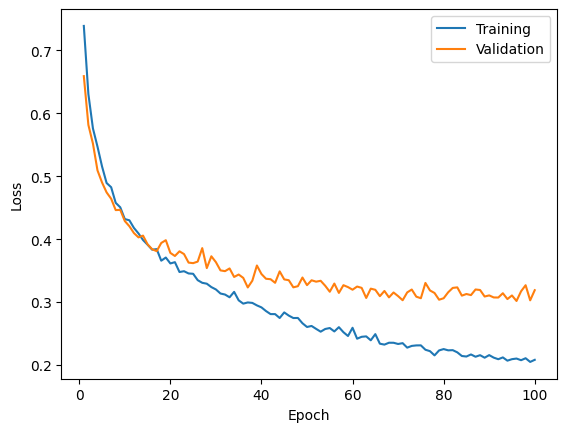

In [175]:
test_model(model1, X_test=X_test, y_test=y_test)
log = pd.read_csv(f"Model_Stats/standard_training.log")
training_loss = log["loss"]
validation_loss = log["val_loss"]
plt.plot(np.arange(1, len(training_loss) + 1), training_loss, label="Training")
plt.plot(np.arange(1, len(validation_loss) + 1), validation_loss, label="Validation")
plt.legend(loc="upper right")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [176]:
# Fixed prior: standard normal, wrapped in Independent
def prior(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    return Sequential([
        tfpl.DistributionLambda(
            lambda t: tfd.Independent(
                tfd.Normal(loc=tf.zeros(n), scale=1.0),
                reinterpreted_batch_ndims=1)
        )
    ])

def posterior(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    return Sequential([
        tfpl.VariableLayer(
            tfpl.MultivariateNormalTriL.params_size(n),
            dtype=dtype,
            initializer=tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05)  # small noise
        ),
        tfpl.MultivariateNormalTriL(n)
    ])


In [177]:
# Not working - ignore loss function
def gauss(y_true, y_pred, epsilon=1e-6):
    mean = y_pred[:, 0]  # predicted mean
    log_var = y_pred[:, 1]  # predicted log variance (aleatoric uncertainty)

    # Stabilize variance calculation: ensure that variance is never zero or too small
    variance = tf.exp(log_var) + epsilon  # Adding epsilon to avoid zero variance
    precision = 1.0 / variance

    # Negative Log-Likelihood: NLL = 0.5 * (log_var + (y_true - mean)^2 / variance)
    nll = 0.5 * (log_var + tf.square(y_true - mean) * precision)

    # Return the mean NLL
    return tf.reduce_mean(nll)

# Bayesian Model
inputs = Input(shape=(52,))
x = tfp.layers.DenseVariational(
    units=16,
    make_prior_fn=prior,
    make_posterior_fn=posterior,
    kl_weight = 1e-6,
    activation='relu')(inputs)
outputs = Dense(1, activation='linear')(x)



model2 = Model(inputs=inputs, outputs=outputs)
model2.compile(optimizer=Adam(1e-4), loss="mse")
log = CSVLogger(f"Model_Stats/bnn_training.log", append=True)
model2.fit(X_train, y_train, epochs=200, validation_split=0.1, callbacks=[log])

Epoch 1/200
 25/165 [===>..........................] - ETA: 3s - loss: 49.2767

KeyboardInterrupt: 

In [ ]:
# Monte Carlo sampling at test time
preds = np.array([model2.predict(X_test, batch_size=64) for _ in range(50)])
mean_preds = preds.mean(axis=0)
print("MSE:", mean_squared_error(y_test, mean_preds))
print("R2:", r2_score(y_test, mean_preds))



40/40 [==============================] - 0s 3ms/step
MSE: 0.8112678028634036
R2: 0.1901147466005707


In [178]:
# Tried plugging in BNN into Chat and changing posterior and prior but got an
# error with params
import tensorflow as tf
import numpy as np
import tensorflow_probability as tfp

# Ensure X_train and y_train are tensors
X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)

# Check shapes of inputs
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

tfd = tfp.distributions
tfpl = tfp.layers

# Define prior function
def prior_fn(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    return tfd.Independent(
        tfd.Normal(loc=tf.zeros(n, dtype=dtype), scale=1.0),
        reinterpreted_batch_ndims=1
    )

# Define posterior function
def posterior_fn(kernel_size, bias_size=0, dtype=None):
    n = kernel_size + bias_size
    c = np.log(np.expm1(1.0))  # Softplus inverse

    def posterior():
        loc = tf.Variable(tf.random.normal([n], stddev=0.1, dtype=dtype), name='posterior_loc')
        raw_scale = tf.Variable(tf.random.normal([n], stddev=0.1, dtype=dtype), name='posterior_scale')
        scale = 1e-5 + tf.nn.softplus(c + raw_scale)
        return tfd.Independent(
            tfd.Normal(loc=loc, scale=scale),
            reinterpreted_batch_ndims=1
        )

    return posterior

# Test prior and posterior functions (optional)
# You can test by printing the outputs
kernel_size = 48  # Your input features
bias_size = 0
dtype = tf.float32

prior = prior_fn(kernel_size, bias_size, dtype)
posterior = posterior_fn(kernel_size, bias_size, dtype)
print(prior)
print(posterior)

# Model inputs
inputs = tf.keras.Input(shape=(48,))  # Input shape of the features

# Apply DenseVariational layer to the inputs, this returns a tensor (not a layer)
output_params = tfpl.DenseVariational(
    units=2,  # 1 for mean, 1 for log variance
    make_posterior_fn=posterior_fn,  # Pass posterior function
    make_prior_fn=prior_fn,  # Pass prior function
    kl_weight=1 / X_train.shape[0],  # KL-divergence weight
)(inputs)  # Apply the layer to the inputs

# Now output_params is a tensor containing both mean and log variance
mean, log_var = output_params[:, 0], output_params[:, 1]  # Split the tensor into mean and log_var

# Define the final output distribution: Normal with the predicted mean and log variance
outputs = tfpl.DistributionLambda(
    lambda t: tfd.Normal(loc=mean, scale=tf.exp(0.5 * log_var))  # Standard deviation is exp(0.5 * log_var)
)(mean)  # You can use 'mean' as the input here, since it already holds the correct values.




X_train shape: (5848, 52)
y_train shape: (5848,)
tfp.distributions.Independent("IndependentNormal", batch_shape=[], event_shape=[48], dtype=float32)
<function posterior_fn.<locals>.posterior at 0x7cba6fb974c0>


AttributeError: 'tuple' object has no attribute 'rank'

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import CSVLogger
from tensorflow.keras.optimizers import Adam

# Define the MCDropout model class
class MCDropoutNet(tf.keras.Model):
  def __init__(self):
      super(MCDropoutNet, self).__init__()
      self.fc1 = tf.keras.layers.Dense(50, activation='relu', input_shape=(52,))
      self.dropout = tf.keras.layers.Dropout(0.2)
      self.fc2 = tf.keras.layers.Dense(1)

  def call(self, inputs, training=False):
      x = self.fc1(inputs)
      x = self.dropout(x, training=training)  # Dropout is active during training and testing
      return self.fc2(x)

# Function for Monte Carlo Dropout Prediction with Uncertainty
def predict_with_uncertainty(f_model, X, n_iter=100):
  f_model.trainable = False  # Disable training (not needed)

  # Predict with dropout active during inference
  predictions = []
  for _ in range(n_iter):
      preds = f_model(X, training=True)  # Set `training=True` to keep dropout active
      predictions.append(preds.numpy())

  predictions = np.array(predictions)
  prediction_mean = predictions.mean(axis=0)
  prediction_std = predictions.std(axis=0)
  return prediction_mean, prediction_std


model = MCDropoutNet()
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
log = CSVLogger('Model_Stats/mc_dropout.log', append=True)

# Train the model and manually log predictions and uncertainties
for epoch in range(200):
  history = model.fit(X_train, y_train, epochs=1, validation_split=0.1, batch_size=32, verbose=0, callbacks=[log])

  # Extract the training and validation loss from the history
  train_loss = history.history['loss'][0]
  val_loss = history.history['val_loss'][0]
  print(f"Epoch {epoch + 1}: Training Loss = {train_loss:.4f}, Validation Loss = {val_loss:.4f}")

  # Predict with uncertainty after each epoch
  prediction_mean, prediction_std = predict_with_uncertainty(model, X_train, n_iter=100)

  # Convert the predictions and uncertainty to a DataFrame
  log_data = pd.DataFrame({
      'epoch': [epoch + 1] * len(prediction_mean),
      'prediction_mean': prediction_mean.flatten(),
      'prediction_std': prediction_std.flatten()
  })

  # Save to CSV (append mode)
  log_data.to_csv('Model_Stats/mc_dropout_predictions.csv', mode='a', header=not pd.io.common.file_exists('Model_Stats/mc_dropout_predictions.csv'), index=False)

print("Training complete.")


Epoch 1: Training Loss = 0.9813, Validation Loss = 0.7531
Epoch 2: Training Loss = 0.7413, Validation Loss = 0.6673
Epoch 3: Training Loss = 0.6635, Validation Loss = 0.6254
Epoch 4: Training Loss = 0.6256, Validation Loss = 0.5958
Epoch 5: Training Loss = 0.6034, Validation Loss = 0.5882
Epoch 6: Training Loss = 0.5920, Validation Loss = 0.5645
Epoch 7: Training Loss = 0.5679, Validation Loss = 0.5515
Epoch 8: Training Loss = 0.5637, Validation Loss = 0.5395
Epoch 9: Training Loss = 0.5522, Validation Loss = 0.5388
Epoch 10: Training Loss = 0.5396, Validation Loss = 0.5278
Epoch 11: Training Loss = 0.5388, Validation Loss = 0.5212
Epoch 12: Training Loss = 0.5297, Validation Loss = 0.5187
Epoch 13: Training Loss = 0.5286, Validation Loss = 0.5175
Epoch 14: Training Loss = 0.5173, Validation Loss = 0.5210
Epoch 15: Training Loss = 0.5188, Validation Loss = 0.5195
Epoch 16: Training Loss = 0.5148, Validation Loss = 0.5184
Epoch 17: Training Loss = 0.5163, Validation Loss = 0.5122
Epoch 

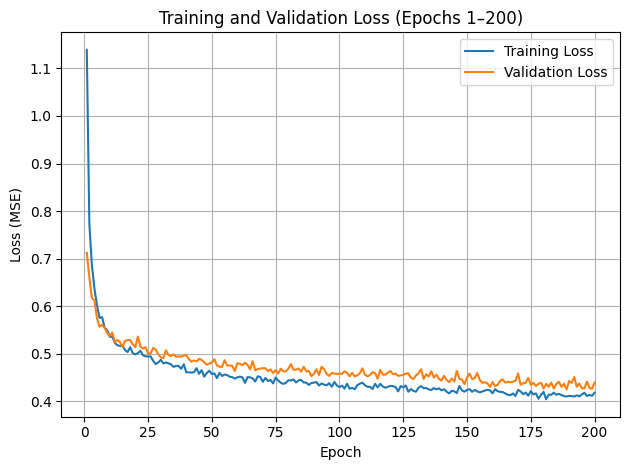

ValueError: Found input variables with inconsistent numbers of samples: [7840, 19536]

In [153]:
log_df = pd.read_csv('Model_Stats/mc_dropout.log')
log_df = log_df.tail(200)
epochs = list(range(1, 201))

plt.plot(epochs, log_df['loss'], label='Training Loss')
plt.plot(epochs, log_df['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training and Validation Loss (Epochs 1–200)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

df = pd.read_csv("Model_Stats/mc_dropout_predictions.csv")

# Get the max epoch (i.e. the last epoch)
last_epoch = df['epoch'].max()

# Filter only the predictions from the last epoch
final_preds = df[df['epoch'] == last_epoch]['prediction_mean'].values

# Then compute metrics using this
r2 = r2_score(y_train, final_preds)
mse = mean_squared_error(y_train, final_preds)
print(f"R² score: {r2}")
print(f"MSE: {mse}")